# Bibliotecas necessarias 


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

O nosso dataset trata-se do Desempenho dos alunos nos exames em diversas disciplinas ao fim do ensino médio.
Inicialmente vamos abrir o arquivo e associasr a uma variavel que vai ser o nosso dataframe


In [3]:
desempenho = pd.read_csv('StudentsPerformance.csv')
desempenho.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
desempenho.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


Vamos verificar quais os rotulos possiveis dos atributos

In [5]:
desempenho['gender'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [6]:
desempenho['race/ethnicity'].unique()

<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str

In [7]:
desempenho['parental level of education'].unique()

<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str

In [8]:
desempenho['lunch'].unique()

<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str

In [9]:
desempenho['test preparation course'].unique()

<StringArray>
['none', 'completed']
Length: 2, dtype: str

Vamos passar as colunas e os rotulos todos para o idioma português e tornar o projeto mais próximo de nosso cotidiano.

In [10]:
desempenho = desempenho.rename(columns={
    'gender': 'genero',
    'race/ethnicity': 'raca_etnia',
    'parental level of education': 'nivel_educacao_pais',
    'lunch': 'tipo_alimentacao',
    'test preparation course': 'curso_preparatorio',
    'math score': 'nota_matematica',
    'reading score': 'nota_leitura',
    'writing score': 'nota_escrita'
})

In [11]:
desempenho['genero'] = desempenho['genero'].replace({
    'female': 'feminino',
    'male': 'masculino'
})

In [12]:
desempenho['tipo_alimentacao'] = desempenho['tipo_alimentacao'].replace({
    'standard': 'padrao',
    'free/reduced': 'gratuito/reduzido'
})

In [13]:
desempenho['curso_preparatorio'] = desempenho['curso_preparatorio'].replace({
    'none': 'nenhum',
    'completed': 'completo'
})

In [14]:
desempenho['nivel_educacao_pais'] = desempenho['nivel_educacao_pais'].replace({
    "bachelor's degree": 'ensino_superior',
    "some college": 'faculdade_incompleta',
    "master's degree": 'mestrado',
    "associate's degree": 'tecnico',
    "high school": 'ensino_medio',
    "some high school": 'medio_incompleto'
})

In [15]:
desempenho['raca_etnia'] = desempenho['raca_etnia'].replace({
    'group A': 'grupo_A',
    'group B': 'grupo_B',
    'group C': 'grupo_C',
    'group D': 'grupo_D',
    'group E': 'grupo_E'
})

Agora vamos ver novamente as cinco primeiras linhas de nosso dataframe traduzido para o português.

In [16]:
desempenho.head()


,genero,raca_etnia,nivel_educacao_pais,tipo_alimentacao,curso_preparatorio,nota_matematica,nota_leitura,nota_escrita
0,feminino,grupo_B,ensino_superior,padrao,nenhum,72,72,74
1,feminino,grupo_C,faculdade_incompleta,padrao,completo,69,90,88
2,feminino,grupo_B,mestrado,padrao,nenhum,90,95,93
3,masculino,grupo_A,tecnico,gratuito/reduzido,nenhum,47,57,44
4,masculino,grupo_C,faculdade_incompleta,padrao,nenhum,76,78,75


# Vamos descrever as estatísticas básicas dos atributos notas de matematica, leitura e escrita.

In [17]:
desempenho.describe()

,nota_matematica,nota_leitura,nota_escrita
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Agora vamos verificar se temos linhas com falta de informação ou com informação nula.

In [18]:
desempenho.isnull().sum()


genero                 0
raca_etnia             0
nivel_educacao_pais    0
tipo_alimentacao       0
curso_preparatorio     0
nota_matematica        0
nota_leitura           0
nota_escrita           0
dtype: int64

# Vamos verificar a porcentagem de meninas e meninas que participaram dos testes

In [19]:
desempenho['genero'].value_counts(normalize=True)*100



genero
feminino     51.8
masculino    48.2
Name: proportion, dtype: float64

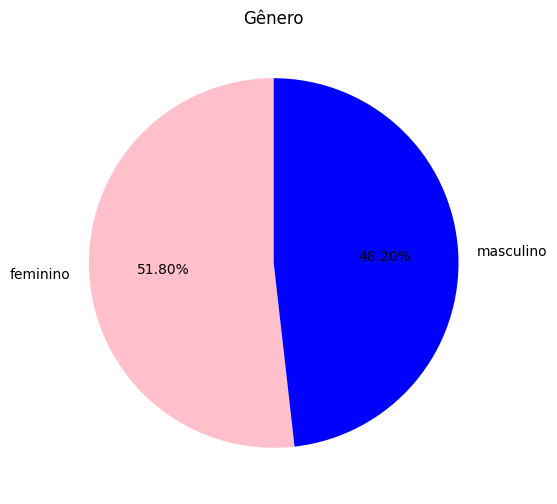

In [22]:
plt.figure(figsize = (18,6))
plt.pie(desempenho['genero'].value_counts(),colors=['pink','blue'],labels=['feminino','masculino'],autopct='%1.2f%%',startangle=90)
plt.title("Gênero")
plt.show()

Podemos observar pelo percentual e pelo gráfico de pizza que tivemos mais mulheres fazendo o teste do homens.

# Agora vamos fazer uma análise do desempenho das notas por gênero

In [20]:
desempenho.groupby(['genero'])['nota_matematica'].mean()

genero
feminino     63.633205
masculino    68.728216
Name: nota_matematica, dtype: float64

In [78]:
desempenho.groupby(['genero'])['nota_matematica'].median()

genero
feminino     65.0
masculino    69.0
Name: nota_matematica, dtype: float64

In [24]:
desempenho.groupby(['genero'])['nota_matematica'].std()

genero
feminino     15.491453
masculino    14.356277
Name: nota_matematica, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em matemática, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, os homens tem um desempenho um pouco melhor do que as mulheres no teste de matemática.Temos uma variabilidade maior das notas em matemática das mulheres em relação ao homens. vamos tentar visualizar isso em um famos gráfico de Boxplot.

C:\Users\CLIENTE\AppData\Local\Temp\ipykernel_42180\771109184.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot( data = desempenho,x = 'genero',y = 'nota_matematica',palette=['pink','blue'])


<Axes: xlabel='genero', ylabel='nota_matematica'>

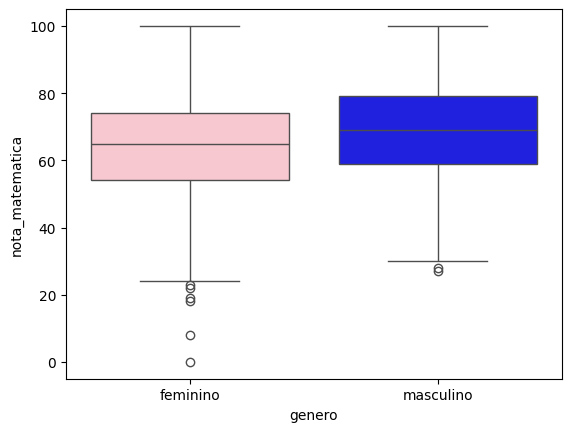

In [27]:
sns.boxplot( data = desempenho,x = 'genero',y = 'nota_matematica',palette=['pink','blue'])


Podemos visualizar novamente uma peguena diferença de desempenho em matemática a favor dos homens ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.A variabilidade maior das notas de matemática para mulheres deve-se algumas valores que estão bem abaixo do primeiro quartil. 

In [59]:
desempenho.groupby(['genero'])['nota_leitura'].mean()

genero
feminino     72.608108
masculino    65.473029
Name: nota_leitura, dtype: float64

In [82]:
desempenho.groupby(['genero'])['nota_leitura'].median()

genero
feminino     73.0
masculino    66.0
Name: nota_leitura, dtype: float64

In [30]:
desempenho.groupby(['genero'])['nota_leitura'].std()

genero
feminino     14.378245
masculino    13.931832
Name: nota_leitura, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em leitura, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de leitura. vamos tentar visualizar isso em um famos gráfico de Boxplot.

C:\Users\CLIENTE\AppData\Local\Temp\ipykernel_42180\2705348539.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = desempenho, x = 'genero', y = 'nota_leitura',palette=['pink','blue'])


<Axes: xlabel='genero', ylabel='nota_leitura'>

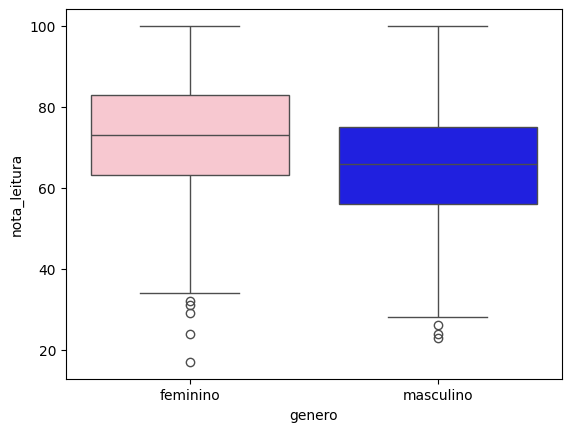

In [28]:
sns.boxplot(data = desempenho, x = 'genero', y = 'nota_leitura',palette=['pink','blue'])

Podemos visualizar novamente uma diferença de desempenho em leitura a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens. Ja neste caso a variabilidade continua sendo maior que a dos homens, mas a mediana é acima da média o que eleva a quantidade de notas altas das mulheres.

In [60]:
desempenho.groupby(['genero'])['nota_escrita'].mean()

genero
feminino     72.467181
masculino    63.311203
Name: nota_escrita, dtype: float64

In [84]:
desempenho.groupby(['genero'])['nota_escrita'].median()

genero
feminino     74.0
masculino    64.0
Name: nota_escrita, dtype: float64

In [31]:
desempenho.groupby(['genero'])['nota_escrita'].std()

genero
feminino     14.844842
masculino    14.113832
Name: nota_escrita, dtype: float64

Observa-se que temos uma diferença no desempenho medio das mulheres em relação aos homens em escrita, algo reforçado pelo nossas medianas, ou seja de acordo com as médias e medianas, as mulheres tem um desempenho melhor do que os homens no teste de escrita. vamos tentar visualizar isso em um famos gráfico de Boxplot.

C:\Users\CLIENTE\AppData\Local\Temp\ipykernel_42180\1852026080.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = desempenho, x = 'genero', y = 'nota_escrita', palette=['pink','blue'])


<Axes: xlabel='genero', ylabel='nota_escrita'>

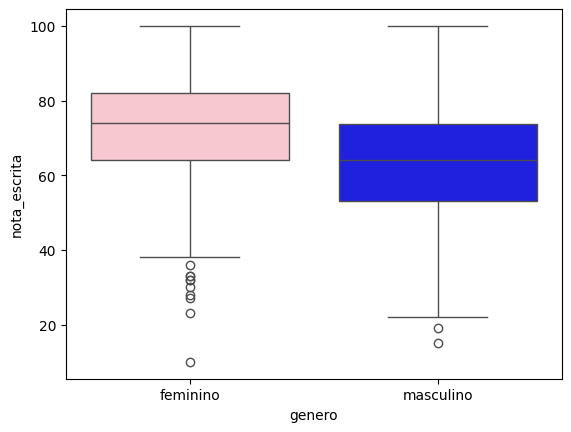

In [32]:
sns.boxplot(data = desempenho, x = 'genero', y = 'nota_escrita', palette=['pink','blue'])

Podemos visualizar novamente uma diferença de desempenho em escrita a favor das mulheres ao mesmo tempo temos que observar alguns pontos bem abaixo do primeiro quartil por parte das mulheres e um box com dados mais dispersos que o dos homens.Acredito que das três comparações esse tenha a diferença mais significativa.

# Porcentagem de pessoas que fizeram os testes por Raça/Etnia

In [33]:
desempenho['raca_etnia'].value_counts(normalize=True)*100

raca_etnia
grupo_C    31.9
grupo_D    26.2
grupo_B    19.0
grupo_E    14.0
grupo_A     8.9
Name: proportion, dtype: float64

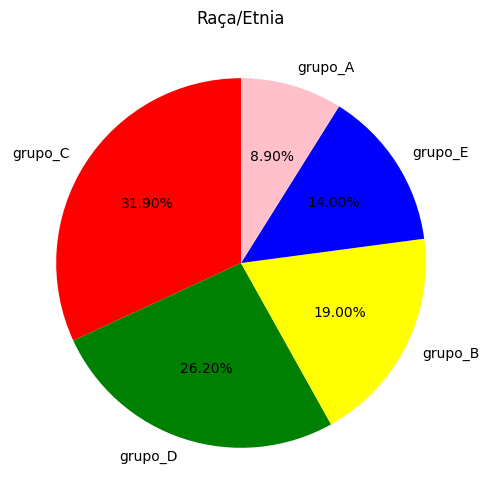

In [35]:
plt.figure(figsize = (18,6))
plt.pie(desempenho['raca_etnia'].value_counts(),colors=['red','green','yellow','blue','pink'],labels=['grupo_C','grupo_D','grupo_B','grupo_E','grupo_A'],autopct='%1.2f%%',startangle=90)
plt.title("Raça/Etnia")
plt.show()

De acordo com as porcentagens e com o gráfico podemos ver que os grupos etnicos C e D somam mais de 50% dos participantes.

# Vamos analisar o desempenho nos testes em relação aos grupos etnicos

In [43]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,61.63,64.67,62.67
grupo_B,63.45,67.35,65.60
grupo_C,64.46,69.10,67.83
grupo_D,67.36,70.03,70.15
grupo_E,73.82,73.03,71.41


In [42]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].median()

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,61.0,64.0,62.0
grupo_B,63.0,67.0,67.0
grupo_C,65.0,71.0,68.0
grupo_D,69.0,71.0,72.0
grupo_E,74.5,74.0,72.0


In [44]:
desempenho.groupby(['raca_etnia'])[['nota_matematica','nota_leitura','nota_escrita']].std()

,nota_matematica,nota_leitura,nota_escrita
raca_etnia,,,
grupo_A,14.523008,15.543762,15.468278
grupo_B,15.468191,15.177499,15.625173
grupo_C,14.852666,13.997033,14.983378
grupo_D,13.769386,13.895306,14.367707
grupo_E,15.534259,14.874024,15.113906


Aqui vou manipular as colunas do dataframe para criar um gráfico de barras e facilitar nosso entendimento

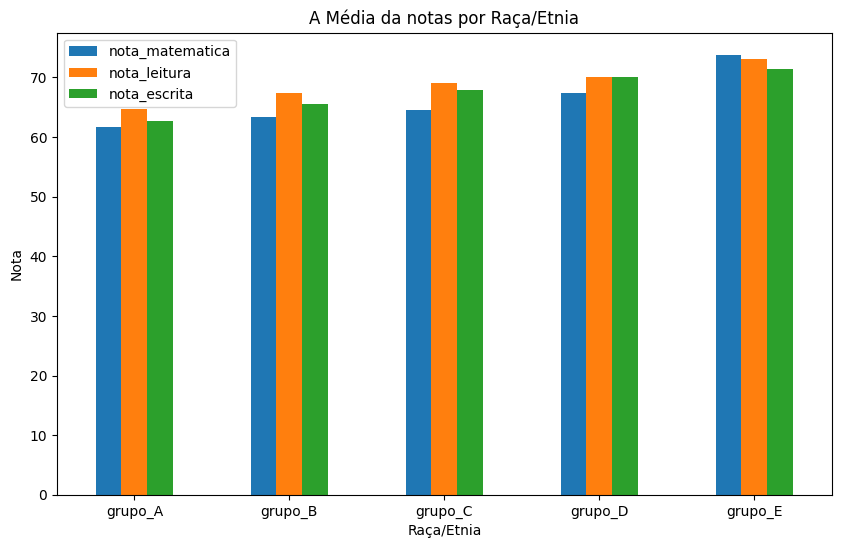

In [41]:
colunas = ['nota_matematica','nota_leitura','nota_escrita']
media_por_grupo = desempenho.groupby('raca_etnia')[colunas].mean()
media_por_grupo.plot(kind='bar',figsize=(10,6))
plt.title("A Média da notas por Raça/Etnia")
plt.ylabel('Nota')
plt.xlabel('Raça/Etnia')
plt.xticks(rotation = 0)
plt.show()

Através dos dados e observando o gráfico de barras, podemos sugerir que o grupo etnico E teve um desempenho melhor em todas as provas ao comparar com os outros grupos etnicos, já o grupo etnico A teve um desempenho inferior a todos os outros grupos etnicos.

# Porcentagem de alunos participantes dos testes de acordo o nível de educação dos pais.

In [ ]:
desempenho['nivel_educacao_pais'].value_counts(normalize=True)*100

nivel_educacao_pais
faculdade_incompleta    22.6
tecnico                 22.2
ensino_medio            19.6
medio_incompleto        17.9
ensino_superior         11.8
mestrado                 5.9
Name: proportion, dtype: float64

# vamos fazer algumas verificações no desempenho dos alunos em função do nível de educação de seus pais em cada teste.

In [71]:
desempenho.groupby(['nivel_educacao_pais'])['nota_matematica'].mean().round(2)

nivel_educacao_pais
ensino_medio            62.14
ensino_superior         69.39
faculdade_incompleta    67.13
medio_incompleto        63.50
mestrado                69.75
tecnico                 67.88
Name: nota_matematica, dtype: float64

In [45]:
desempenho.groupby(['nivel_educacao_pais'])['nota_matematica'].median().round(2)

nivel_educacao_pais
ensino_medio            63.0
ensino_superior         68.0
faculdade_incompleta    67.5
medio_incompleto        65.0
mestrado                73.0
tecnico                 67.0
Name: nota_matematica, dtype: float64

In [46]:
desempenho.groupby(['nivel_educacao_pais'])['nota_matematica'].std().round(2)

nivel_educacao_pais
ensino_medio            14.54
ensino_superior         14.94
faculdade_incompleta    14.31
medio_incompleto        15.93
mestrado                15.15
tecnico                 15.11
Name: nota_matematica, dtype: float64

Aqui podemos observar que de acordo que o nível de instrução dos pais aumentam o desempenho do aluno em matemática também tende a aumentar.Vamos ver isso melhor em um gráfico.

Para fazer essa avaliação visual de uma maneira bem intuitiva, vamos ter que fazer uma ordenação nos rótulos das coluna de nivel de educação dos pais.E para isso vamos criar uma coluna especificamente para utilizar nesses gráficos.Essa coluna será chamada de nivel_educacao_pais2.

In [48]:
ordenado = [ 'medio_incompleto','ensino_medio','tecnico','faculdade_incompleta','ensino_superior','mestrado']
desempenho['nivel_educacao_pais2'] = pd.Categorical(desempenho['nivel_educacao_pais'],categories=ordenado, ordered = True)
grafico_linha = desempenho.groupby(['genero','nivel_educacao_pais2'])[['nota_matematica','nota_leitura','nota_escrita']].mean().reset_index()

Agora que colocamos os rotulos em ordem e criamos a nova coluna vamos traçar o gráfico de linha.

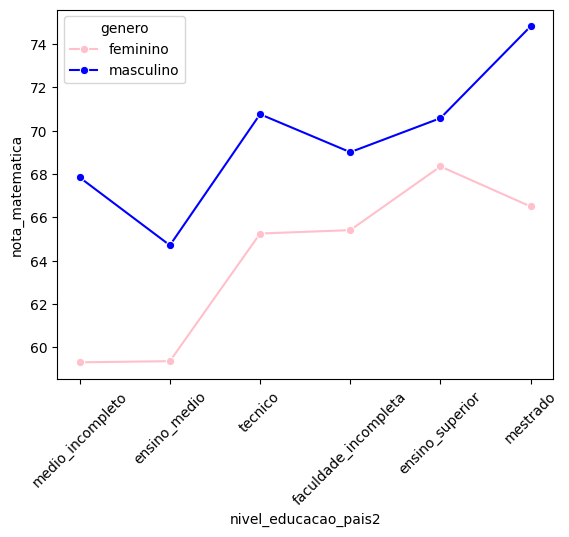

In [54]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_matematica', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

E interessante observar que intuitivamente esperavamos esse comportamento desse gráfico, ou seja conforme o nível de instrução dos país se eleva o desempenho dos alunos seja maior.Outra observação é que as o desempenho dos meninos quando seus pais tem formação superior incompleta ou acima suas notas de uma manmeira rápida. O que surpreende é essa mudança drástica no caso do desempenho das notas das meninas quando seus pais tem mestrado.Nesse deveriamos fazer uma análise mais detalhada para esses caso específico o que sai de nosso objetivo nesse trabalho.

In [72]:
desempenho.groupby(['nivel_educacao_pais'])['nota_leitura'].mean().round(2)

nivel_educacao_pais
ensino_medio            64.70
ensino_superior         73.00
faculdade_incompleta    69.46
medio_incompleto        66.94
mestrado                75.37
tecnico                 70.93
Name: nota_leitura, dtype: float64

In [50]:
desempenho.groupby(['nivel_educacao_pais'])['nota_leitura'].median().round(2)

nivel_educacao_pais
ensino_medio            66.0
ensino_superior         73.0
faculdade_incompleta    70.5
medio_incompleto        67.0
mestrado                76.0
tecnico                 72.5
Name: nota_leitura, dtype: float64

In [51]:
desempenho.groupby(['nivel_educacao_pais'])['nota_leitura'].std().round(2)

nivel_educacao_pais
ensino_medio            14.13
ensino_superior         14.29
faculdade_incompleta    14.06
medio_incompleto        15.48
mestrado                13.78
tecnico                 13.87
Name: nota_leitura, dtype: float64

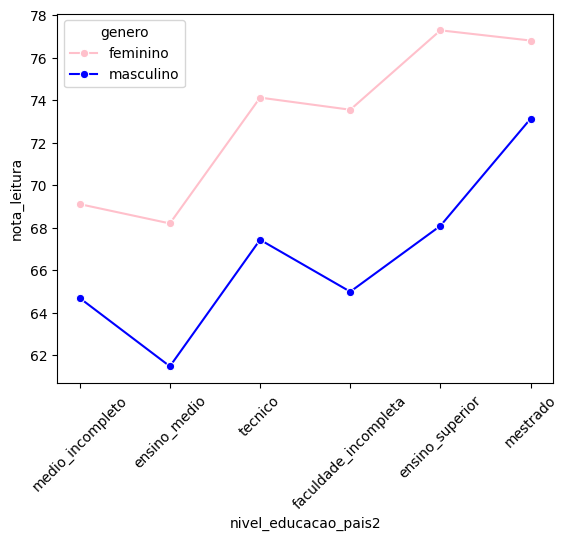

In [53]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_leitura', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

Como já tinhamos visto as meninas em geral tem o desempenho melhor em leitura do os meninos, mas o que surpreende nesse gráfico é a mudança brusca das notas dos meninos ou seja quando os pais tem uma faculdade incompleta ou acima disso o desempenho dos meninos em leitura aumenta bruscamente.

In [73]:
desempenho.groupby(['nivel_educacao_pais'])['nota_escrita'].mean().round(2)

nivel_educacao_pais
ensino_medio            62.45
ensino_superior         73.38
faculdade_incompleta    68.84
medio_incompleto        64.89
mestrado                75.68
tecnico                 69.90
Name: nota_escrita, dtype: float64

In [56]:
desempenho.groupby(['nivel_educacao_pais'])['nota_escrita'].median().round(2)

nivel_educacao_pais
ensino_medio            64.0
ensino_superior         74.0
faculdade_incompleta    70.0
medio_incompleto        66.0
mestrado                75.0
tecnico                 70.5
Name: nota_escrita, dtype: float64

In [57]:
desempenho.groupby(['nivel_educacao_pais'])['nota_escrita'].std().round(2)

nivel_educacao_pais
ensino_medio            14.09
ensino_superior         14.73
faculdade_incompleta    15.01
medio_incompleto        15.74
mestrado                13.73
tecnico                 14.31
Name: nota_escrita, dtype: float64

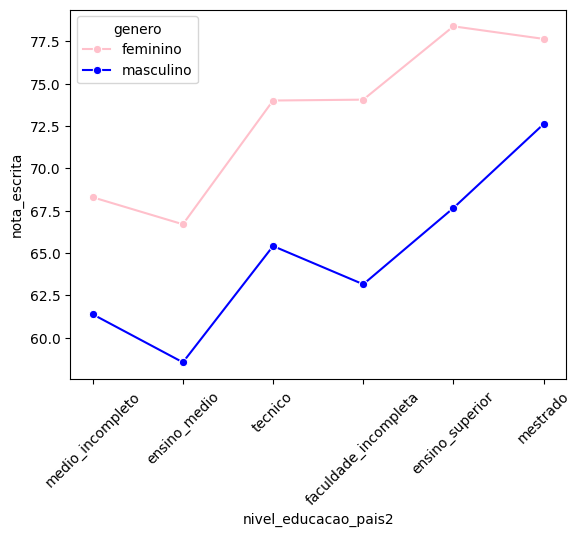

In [58]:
sns.lineplot(data = grafico_linha, x = 'nivel_educacao_pais2',y = 'nota_escrita', hue = 'genero',marker = 'o',palette=['pink','blue'] )
plt.xticks(rotation = 45)
plt.show()

Como já tinhamos visto as meninas em geral tem o desempenho melhor em escrita do que os meninos, mas o que surpreende nesse gráfico é a mudança brusca das notas dos meninos ou seja quando os pais tem uma faculdade incompleta ou acima disso o desempenho dos meninos escrita aumenta bruscamente.

Agora a seguir temos uma tabela que basicamente nos informa o que esta nos gráficos, mas com um tabela maior e com mais atributos.

In [62]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_matematica'].mean().round(2)

genero     nivel_educacao_pais 
feminino   ensino_medio            59.35
           ensino_superior         68.35
           faculdade_incompleta    65.41
           medio_incompleto        59.30
           mestrado                66.50
           tecnico                 65.25
masculino  ensino_medio            64.71
           ensino_superior         70.58
           faculdade_incompleta    69.01
           medio_incompleto        67.84
           mestrado                74.83
           tecnico                 70.76
Name: nota_matematica, dtype: float64

In [63]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_leitura'].mean().round(2)

genero     nivel_educacao_pais 
feminino   ensino_medio            68.20
           ensino_superior         77.29
           faculdade_incompleta    73.55
           medio_incompleto        69.11
           mestrado                76.81
           tecnico                 74.12
masculino  ensino_medio            61.48
           ensino_superior         68.09
           faculdade_incompleta    64.99
           medio_incompleto        64.69
           mestrado                73.13
           tecnico                 67.43
Name: nota_leitura, dtype: float64

In [64]:
desempenho.groupby(['genero','nivel_educacao_pais'])['nota_escrita'].mean().round(2)

genero     nivel_educacao_pais 
feminino   ensino_medio            66.69
           ensino_superior         78.38
           faculdade_incompleta    74.05
           medio_incompleto        68.29
           mestrado                77.64
           tecnico                 74.00
masculino  ensino_medio            58.54
           ensino_superior         67.65
           faculdade_incompleta    63.15
           medio_incompleto        61.38
           mestrado                72.61
           tecnico                 65.41
Name: nota_escrita, dtype: float64

# Vamos analisar agora a questão da alimentação com o desempenho.

In [50]:
desempenho['tipo_alimentacao'].value_counts(normalize=True)*100

tipo_alimentacao
padrao               64.5
gratuito/reduzido    35.5
Name: proportion, dtype: float64

In [70]:
desempenho.groupby(['tipo_alimentacao'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
tipo_alimentacao,,,
gratuito/reduzido,58.92,64.65,63.02
padrao,70.03,71.65,70.82


Parei aqui no dia 20/04/2026

In [51]:
desempenho['curso_preparatorio'].value_counts(normalize=True)*100

curso_preparatorio
nenhum      64.2
completo    35.8
Name: proportion, dtype: float64

In [74]:
desempenho.groupby(['curso_preparatorio'])[['nota_matematica','nota_leitura','nota_escrita']].mean().round(2)

,nota_matematica,nota_leitura,nota_escrita
curso_preparatorio,,,
completo,69.70,73.89,74.42
nenhum,64.08,66.53,64.50


Calculando as médias de notas dos alunos por sexo e materia

In [54]:
media_homens_matematica = desempenho[desempenho['genero']== 'masculino']['nota_matematica'].mean().round(2)
media_mulheres_matematica = desempenho[desempenho['genero']== 'feminino']['nota_matematica'].mean().round(2)
media_homens_leitura = desempenho[desempenho['genero']== 'masculino']['nota_leitura'].mean().round(2)
media_mulheres_leitura = desempenho[desempenho['genero']== 'feminino']['nota_leitura'].mean().round(2)
media_homens_escrita = desempenho[desempenho['genero']== 'masculino']['nota_escrita'].mean().round(2)
media_mulheres_escrita = desempenho[desempenho['genero']== 'feminino']['nota_escrita'].mean().round(2)
print('***************************************************************************')
print('------------------- Notas de acordo com Sexo -------------------------')
print('Nota média dos homens em matemática' ,media_homens_matematica)
print('Nota média das mulheres em matematica' ,media_mulheres_matematica)
print('Nota média dos homens em leitura' ,media_homens_leitura)
print('Nota média das mulheres em leitura' ,media_mulheres_leitura)
print('Nota média dos homens em escrita' ,media_homens_escrita)
print('Nota média das mulheres em escrita' ,media_mulheres_escrita)
print('****************************************************************************')


***************************************************************************
------------------- Notas de acordo com Sexo -------------------------
Nota média dos homens em matemática 68.73
Nota média das mulheres em matematica 63.63
Nota média dos homens em leitura 65.47
Nota média das mulheres em leitura 72.61
Nota média dos homens em escrita 63.31
Nota média das mulheres em escrita 72.47
****************************************************************************


Vamos verificar a média em relação a ter feito ou não curso preparatório.

In [57]:
desempenho.groupby(['genero', 'curso_preparatorio'])['nota_matematica'].mean()

genero     curso_preparatorio
feminino   completo              67.195652
           nenhum                61.670659
masculino  completo              72.339080
           nenhum                66.688312
Name: nota_matematica, dtype: float64